# Caderno teste para mostrar funcionalidades do Python e Jupyter Notebook

## Importa bibliotecas necessárias para rodar o código.

Estas bibliotecas estão sendo instaladas pelo gerenciador de pacotes `uv`.
As bibliotecas vem do repositório <https://pypi.org>.

VER: <https://en.wikipedia.org/wiki/Package_manager>

VER: <https://pypi.org/>

VER:<https://docs.astral.sh/uv/>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Funções para processamento
def extract_freq(wav_file):
    # processamento do arquivo .wav
    return


def extract_time(wav_file):
    return

    
# data can be wav file or .csv
def extract_amp(data):
    return


## Funções para plotagem

VER: Livro Tal, pagina Tal, capitulo Tal

In [3]:
def generate_fake_polar_data(
    n_angles=360,
    base_level=0.0,
    lobe_gain=12.0,
    lobe_direction_deg=45.0,
    lobe_width_deg=35.0,
    noise_std=0.5,
):
    """
    Generate synthetic polar directivity data.

    Parameters
    ----------
    n_angles : int
        Number of angular samples.
    base_level : float
        Baseline magnitude level.
    lobe_gain : float
        Peak gain of the main lobe.
    lobe_direction_deg : float
        Direction of the main lobe in degrees.
    lobe_width_deg : float
        Width (spread) of the lobe in degrees.
    noise_std : float
        Standard deviation of additive Gaussian noise.

    Returns
    -------
    theta_rad : ndarray
        Angles in radians.
    magnitude : ndarray
        Synthetic magnitude values.
    """
    theta_deg = np.linspace(0, 360, n_angles, endpoint=False)
    theta_rad = np.deg2rad(theta_deg)

    # Wrapped angular distance
    delta = (theta_deg - lobe_direction_deg + 180) % 360 - 180

    # Gaussian-shaped directivity lobe
    main_lobe = lobe_gain * np.exp(
        -(delta**2) / (2 * lobe_width_deg**2)
    )

    # Small rear attenuation feature
    rear_lobe = 0.3 * lobe_gain * np.exp(
        -((delta - 180) ** 2) / (2 * (lobe_width_deg * 1.5) ** 2)
    )

    noise = np.random.normal(0, noise_std, size=n_angles)

    magnitude = base_level + main_lobe + rear_lobe + noise

    return theta_rad, magnitude


def plot_polar(
    theta_rad,
    magnitude,
    title="Polar Plot",
    r_label="Magnitude",
    close_curve=True,
):
    """
    Plot polar data.

    Parameters
    ----------
    theta_rad : ndarray
        Angles in radians.
    magnitude : ndarray
        Radial values.
    title : str
        Plot title.
    r_label : str
        Radial axis label.
    close_curve : bool
        If True, repeats first point to close the curve.
    """
    theta = np.asarray(theta_rad)
    radius = np.asarray(magnitude)

    if close_curve:
        theta = np.append(theta, theta[0])
        radius = np.append(radius, radius[0])

    fig, ax = plt.subplots(subplot_kw={"projection": "polar"})

    ax.plot(theta, radius, linewidth=2)
    ax.fill(theta, radius, alpha=0.2)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(title)
    ax.set_rlabel_position(135)
    ax.set_ylabel(r_label)

    ax.grid(True)

    plt.show()


## Utilizando as funções definidas acima

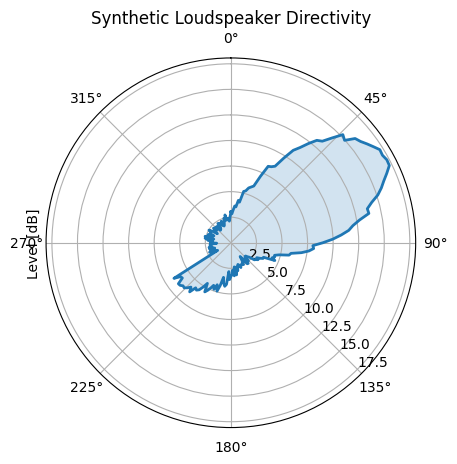

In [4]:
theta_rad, magnitude = generate_fake_polar_data(
    n_angles=180,
    base_level=2,
    lobe_gain=15,
    lobe_direction_deg=60,
    lobe_width_deg=25,
    noise_std=0.3,
)

plot_polar(
    theta_rad,
    magnitude,
    title="Synthetic Loudspeaker Directivity",
    r_label="Level [dB]",
)